# Лабораторная работа № 2.1 — Простая итерация и Ньютон для одного уравнения

Вариант 6. Запускай ячейки сверху вниз. Все исходные данные заданы в ноутбуке, поэтому его можно открыть отдельно от файлов input.txt и output.txt.

Ищем положительный корень exp(x)-2x-2=0 на [1,2]. Простая итерация использует x=ln(2x+2), Ньютон — касательную к графику.

## Исходные данные

Числа ниже соответствуют файлу input.txt этой работы.

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from typing import List

rows = [[1.0, 2.0], [1e-06]]
(a, b), (eps,) = rows
print('Отрезок:', (a, b), 'ε =', eps)

Отрезок: (1.0, 2.0) ε = 1e-06


## Функция и сходимость

На отрезке [1,2] функция меняет знак. Производная итерационной функции не превосходит q=0.5.

In [2]:
def f(x):
    return math.exp(x) - 2 * x - 2


def df(x):
    return math.exp(x) - 2


def ddf(x):
    return math.exp(x)


def phi(x):
    return math.log(2 * x + 2)


def dphi(x):
    return 1 / (x + 1)


def convergence_data(a, b, eps, max_iter):
    """Validate an increasing positive-root interval and a contraction on it."""
    if not math.isfinite(eps) or eps <= 0:
        raise ValueError("eps must be finite and positive")
    if not isinstance(max_iter, int) or max_iter <= 0:
        raise ValueError("max_iter must be a positive integer")
    if not all(math.isfinite(x) for x in (a, b)) or not 0 < a < b:
        raise ValueError("The interval must satisfy 0 < a < b")
    if f(a) > 0 or f(b) < 0 or df(a) <= 0:
        raise ValueError("The interval must bracket the positive root with f' > 0")
    q = dphi(a)  # phi' decreases throughout a positive interval.
    if q >= 1 or not (a <= phi(a) <= phi(b) <= b):
        raise ValueError("phi must map the interval into itself with q < 1")
    return q, df(a)

In [3]:
q, min_df = convergence_data(a, b, eps, 1000)
print('f(a), f(b) =', f(a), f(b), 'q =', q)

f(a), f(b) = -1.281718171540955 1.3890560989306504 q = 0.5


## Два способа уточнения

Простая итерация повторяет φ(x). Ньютон вычисляет x−f(x)/f′(x). История шагов нужна для показа скорости сходимости.

In [4]:
def simple_iteration_method(a, b, eps, max_iter=1000, history=None):
    q, _ = convergence_data(a, b, eps, max_iter)
    x = (a + b) / 2
    for iters in range(1, max_iter + 1):
        x_next = phi(x)
        step = abs(x_next - x)
        error_bound = q / (1 - q) * step
        residual = abs(f(x_next))
        if history is not None:
            history.append(dict(iteration=iters, x=x_next, step=step,
                                error_bound=error_bound, residual=residual))
        if error_bound <= eps and residual <= eps:
            return x_next, iters
        x = x_next
    raise RuntimeError("Simple iteration did not converge within max_iter")


def newton_method(a, b, eps, max_iter=1000, history=None):
    _, m1 = convergence_data(a, b, eps, max_iter)
    # f'' > 0; f(b) >= 0 implies monotone convergence from the right.
    x = b
    for iters in range(1, max_iter + 1):
        derivative = df(x)
        if derivative == 0:
            raise ArithmeticError("Newton derivative is zero")
        x_next = x - f(x) / derivative
        if not math.isfinite(x_next) or not a <= x_next <= b:
            raise ArithmeticError("Newton iterate left the validated interval")
        residual = abs(f(x_next))
        # Mean value theorem: |x - x*| <= |f(x)| / min |f'|.
        error_bound = residual / m1
        if history is not None:
            history.append(dict(iteration=iters, x=x_next, step=abs(x_next-x),
                                error_bound=error_bound, residual=residual))
        if error_bound <= eps and residual <= eps:
            return x_next, iters
        x = x_next
    raise RuntimeError("Newton method did not converge within max_iter")

In [5]:
simple_history, newton_history = [], []
x_simple, n_simple = simple_iteration_method(a, b, eps, history=simple_history)
x_newton, n_newton = newton_method(a, b, eps, history=newton_history)
print('Простая итерация:', x_simple, 'шагов:', n_simple)
print('Ньютон:', x_newton, 'шагов:', n_newton)
print('Первый шаг Ньютона:', newton_history[0]['x'])

Простая итерация: 1.6783467972443524 шагов: 14
Ньютон: 1.678346990061886 шагов: 4
Первый шаг Ньютона: 1.742245010363451


## График

График показывает результат вычисления на тех же исходных данных.

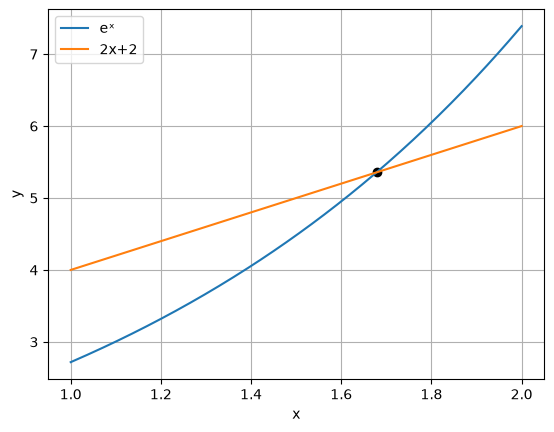

In [6]:
grid = np.linspace(1, 2, 250)
plt.plot(grid, np.exp(grid), label='eˣ')
plt.plot(grid, 2*grid+2, label='2x+2')
plt.scatter([x_newton], [math.exp(x_newton)], color='black')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.legend()
plt.show()

## Самопроверка

Почему найденные числа можно считать корнями с заданной точностью?

In [7]:
assert abs(f(x_simple)) <= eps and abs(f(x_newton)) <= eps
assert abs(x_simple-x_newton) < 2*eps
print('Невязки:', abs(f(x_simple)), abs(f(x_newton)))

Невязки: 6.470775466560497e-07 1.5180701140593555e-10
